In [2]:
import os
import shutil
import random

# Paths
all_images_dir = r"C:\Users\shris\CC\Flickr8k_Dataset\Flicker8k_Dataset"
subset_file = r"C:\Users\shris\CC\Flickr8k_text (1)\Flickr_8k.trainImages.txt"
output_dir = r"C:\Users\shris\NewCaptionCraft\Images"
output_names_file = r"C:\Users\shris\NewCaptionCraft\text.txt"

# Make sure output folder exists
os.makedirs(output_dir, exist_ok=True)

# Load 6000 image names
with open(subset_file, 'r') as f:
    image_names = [line.strip() for line in f.readlines()]

# Randomly select 1000 images
selected_names = random.sample(image_names, 1000)

# Copy selected images to new folder and record their names
with open(output_names_file, 'w') as out_file:
    for name in selected_names:
        src_path = os.path.join(all_images_dir, name)
        dst_path = os.path.join(output_dir, name)
        if os.path.exists(src_path):  # Ensure the image exists
            shutil.copy2(src_path, dst_path)
            out_file.write(name + '\n')


In [4]:
!pip install tensorflow
!pip install Keras
!pip install pillow
!pip install NumPy
!pip install tqdm
!pip install jupyterlab

In [3]:
# Paths
selected_names_file = r"C:\Users\shris\NewCaptionCraft\text.txt"  # 1000 selected image names
original_token_file = r"C:\Users\shris\CC\Flickr8k_text (1)\Flickr8k.token.txt"
new_token_file = r"C:\Users\shris\NewCaptionCraft\selected_token.txt"

# Load selected image names into a set for faster lookup
with open(selected_names_file, 'r') as f:
    selected_images = set(line.strip() for line in f.readlines())

# Read from the original token file and write matching lines
with open(original_token_file, 'r') as infile, open(new_token_file, 'w') as outfile:
    for line in infile:
        image_id = line.split('\t')[0].split('#')[0]
        if image_id in selected_images:
            outfile.write(line)


In [4]:
import numpy as np
from PIL import Image
import os
import string
from keras.applications.xception import Xception #to get pre-trained model Xception For feature extraction
from keras.applications.xception import preprocess_input #to match xception model format
from keras.preprocessing.image import load_img #to load image
from keras.preprocessing.image import img_to_array#to convert it into array
#from keras.preprocessing.text import Tokenizer #for text tokenization
from tensorflow.keras.preprocessing.text import Tokenizer #to convert text into seq of integers

from keras.preprocessing.sequence import pad_sequences#for uniformity(all seq has same length for short pad with zeros)
from keras.utils import to_categorical#convert class vector into binary class matrice
#from keras.layers.merge import add
from tensorflow.keras.layers import add#combine output from different layers
#Model building components
from keras.models import Model, load_model
from keras.layers import Input, Dense#Keras to build our CNN and LSTM dense is fully connected neural network layer
from keras.layers import LSTM, Embedding, Dropout#Embedding converts integer sequence into dense vector representation
from tqdm.notebook import tqdm  # Use this instead of tqdm_notebook
#Dropout a regularization technique to prevent OVERFITTING by setting input units to 0.
tqdm().pandas()#Integrate tqdm with pandas
import pickle as pkl

0it [00:00, ?it/s]

In [5]:
import string

# Load the document file into memory
def load_fp(filename):
    # Open file to read
    with open(filename, 'r') as file:  # Using 'with' ensures proper file closure
        text = file.read()
    return text

# Get all images with their captions
def img_capt(filename):
    file = load_fp(filename)
    captions = file.split('\n')  # Fixed incorrect split delimiter
    descriptions = {}

    for caption in captions[:-1]:
        img, caption = caption.split('\t',1)  # Fixed incorrect split delimiter
        img = img[:-2]  # Removing last two characters of the image name

        if img not in descriptions:
            descriptions[img] = [caption]
        else:
            descriptions[img].append(caption)
    
    return descriptions

# Data cleaning function will convert all uppercase alphabets to lowercase, remove punctuations, and words containing numbers
def txt_clean(captions):
    table = str.maketrans('', '', string.punctuation)

    for img, caps in captions.items():
        for i, img_caption in enumerate(caps):
            img_caption = img_caption.replace("-", " ")
            descp = img_caption.split()

            # Convert to lowercase
            descp = [wrd.lower() for wrd in descp]
            # Remove punctuation from each token
            descp = [wrd.translate(table) for wrd in descp]
            # Remove hanging 's and 'a'
            descp = [wrd for wrd in descp if len(wrd) > 1]
            # Remove words containing numbers
            descp = [wrd for wrd in descp if wrd.isalpha()]

            # Converting back to string
            img_caption = ' '.join(descp)
            captions[img][i] = img_caption

    return captions

# To build vocab of all unique words
def txt_vocab(descriptions):
    vocab = set()
    for key in descriptions.keys():
        [vocab.update(d.split()) for d in descriptions[key]]
    return vocab

# To save all descriptions in one file
def save_descriptions(descriptions, filename):
    lines = []
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + '\t' + desc)  # Fixed incorrect escape character
    data = "\n".join(lines)  # Fixed incorrect escape character

    with open(filename, "w") as file:  # Using 'with' ensures proper file closure
        file.write(data)

# Set these paths according to the project folder in your system
dataset_text =  r"C:\Users\shris\NewCaptionCraft\text.txt"  # Using raw string (r"")
dataset_images = r"C:\Users\shris\NewCaptionCraft\Images" # Using raw string

# To prepare our text data
filename = r"C:\Users\shris\NewCaptionCraft\selected_token.txt"


# Loading the file that contains all data and mapping them into a descriptions dictionary
descriptions = img_capt(filename)
print("Length of descriptions =", len(descriptions))

# Cleaning the descriptions
clean_descriptions = txt_clean(descriptions)

# To build vocabulary
vocabulary = txt_vocab(clean_descriptions)
print("Length of vocabulary =", len(vocabulary))

# Saving all descriptions in one file
save_descriptions(clean_descriptions, "descriptions.txt")


Length of descriptions = 1000
Length of vocabulary = 3207


In [6]:
model = Xception( include_top=False, pooling="avg" )
#include_top=false because we are using model for only feature extraction no classification
#pooling when include_top=false model's output is a 4d tensor pooling specifies how to reduce this tensor to lower dimensional representation

In [7]:
dirc="C://Users/shris/NewCaptionCraft/Images"

In [8]:
def extract_features(directory):
    model = Xception( include_top=False, pooling='avg' )#2048 feature vector
    features = {}
    a=1
    for pic in tqdm(os.listdir(dirc)):
        file =dirc +"/" +pic
        image = Image.open(file)
        image = image.resize((299,299))
        image = np.expand_dims(image, axis=0)
        #image = preprocess_input(image)
        image = image/127.5
        image = image - 1.0
        feature = model.predict(image)
        features[pic] = feature
    return features

features = extract_features(dirc)
pkl.dump(features, open("features.p","wb"))
#to directly load the features from the pickle file.
features = pkl.load(open("features.p","rb"))

  0%|          | 0/1824 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 821ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [9]:
def load_doc(filename):
    """Load the contents of a file and return as a single string."""
    with open(filename, "r", encoding="utf-8") as file:
        return file.read()

def load_photos(filename):
    file = load_doc(filename)
    photos = file.split("\n")[:-1]
    return photos

def load_clean_descriptions(filename, photos):
    # Loading clean descriptions
    file = load_doc(filename)
    descriptions = {}
    
    for line in file.split("\n"):
        words = line.split()
        if len(words) < 1:
            continue
        image, image_caption = words[0], words[1:]
        if image in photos:
            if image not in descriptions:
                descriptions[image] = []
            desc = ' ' + " ".join(image_caption) + ' '
            descriptions[image].append(desc)
    
    return descriptions

def load_features(photos):
    # Loading all features
    from pickle import load
    all_features = load(open("features.p", "rb"))
    # Selecting only needed features
    features = {k: all_features[k] for k in photos if k in all_features}
    return features

filename = r"C:\Users\shris\NewCaptionCraft\text.txt"
# train = loading_data(filename)
train_imgs = load_photos(filename)
train_descriptions = load_clean_descriptions("descriptions.txt", train_imgs)
train_features = load_features(train_imgs)


# Tokenization

In [7]:
# Convert dictionary to a list of descriptions
def dict_to_list(descriptions):
    all_desc = []
    for key in descriptions.keys():
        [all_desc.append(d) for d in descriptions[key]]
    return all_desc

# Creating tokenizer class to vectorize text corpus
from tensorflow.keras.preprocessing.text import Tokenizer
from pickle import dump

def create_tokenizer(descriptions):
    desc_list = dict_to_list(descriptions)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(desc_list)
    return tokenizer

# Example usage
tokenizer = create_tokenizer(train_descriptions)
dump(tokenizer, open('tokenizer.p', 'wb'))
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {vocab_size}")  # Example output

# Calculate maximum length of descriptions
#def max_length(descriptions):
def get_max_length(descriptions):
    desc_list = dict_to_list(descriptions)
    return max(len(d.split()) for d in desc_list)

max_length = get_max_length(train_descriptions)
print(f"Max description length: {max_length}")


Vocabulary size: 3126
Max description length: 33


In [8]:
print(type(max_length))  # Should print: <class 'int'>

<class 'int'>


# CNN+LSTM

In [9]:
# Data generator, used by model.fit_generator()
#CNN
def data_generator(descriptions2, features, tokenizer, max_length):
    while 1:
        for key, description_list in descriptions2.items():
            # Retrieve photo features
            feature = features[key][0]
            feature
            inp_image, inp_seq, op_word = create_sequences(tokenizer, max_length, description_list, feature)
            #yield [[inp_image, inp_seq], op_word]
            yield((inp_image, inp_seq),op_word)
#LSTM
def create_sequences(tokenizer, max_length, desc_list, feature):
    x_1, x_2, y = list(), list(), list()
    # Move through each description for the image
    for desc in desc_list:
        # Encode the sequence 
        #For a caption like ['start', 'a', 'man', 'riding', 'bike', 'end'], it creates pairs:
        #Input: ['start'], Output: 'a'
        #Input: ['start', 'a'], Output: 'man' predicts sequence
        seq = tokenizer.texts_to_sequences([desc])[0]
        # Divide one sequence into various X, y pairs
        for i in range(1, len(seq)):
            # Divide into input and output pair
            in_seq, out_seq = seq[:i], seq[i]
            # Pad input sequence for uniformity
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            # Encode output sequence
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            # Store
            x_1.append(feature)
            x_2.append(in_seq)
            y.append(out_seq)
    return np.array(x_1), np.array(x_2), np.array(y)

# Calculate max_length before using it in data_generator
# This should return an integer value


# To check the shape of the input and output for your model
[a, b], c = next(data_generator(train_descriptions, features, tokenizer, max_length))
print(a.shape, b.shape, c.shape)
# Example output: (47, 2048), (47, 32), (47, 7577)

(35, 2048) (35, 33) (35, 3126)


# Encoder Decoder
Encoder (CNN): Processes the input image to extract meaningful features.
Decoder (LSTM): Generates a sequence of words (caption) based on the extracted image features.​

In [10]:
from keras.utils import plot_model
# define the captioning model
def define_model(vocab_size, max_length):
  # features from the CNN model compressed from 2048 to 256 nodes
    inputs1 = Input(shape=(2048,))
    fe1 = Dropout(0.5)(inputs1) #regularization with rate 50% to avoid overfitting
    fe2 = Dense(256, activation='relu')(fe1)#Reduces the dimensionality of the image features to 256 and introduces non-linearity.
  # LSTM sequence model
    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)
  # Merging both models
    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)
  # merge it [image, seq] [word]
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
  # summarize model
    print(model.summary())
   #plot_model(model, to_file='model.png', show_shapes=True)
    return model

In [18]:
# Train our model
print('Dataset: ', len(train_imgs))
print('Descriptions: train=', len(train_descriptions))
print('Photos: train=', len(train_features))
print('Vocabulary Size:', vocab_size)
print('Description Length: ', max_length)

model = define_model(vocab_size, max_length)
epochs = 20
steps = len(train_descriptions)

# Creating a directory named 'models' to save our models
os.makedirs("models2", exist_ok=True)

for i in range(epochs):
    generator = data_generator(train_descriptions, train_features, tokenizer, max_length)
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)
    #model.save("models/model_" + str(i) + ".h5")
    model.save("models2/model_" + str(i) + ".keras")

Dataset:  1000
Descriptions: train= 1000
Photos: train= 1000
Vocabulary Size: 3126
Description Length:  33


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 33)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 2048)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 33, 256)           │         800,256 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 2048)              │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 33, 256)           │               0 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 33)                │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256)               │         524,544 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 256)               │         525,312 │ dropout_1[0][0],           │
│                               │                           │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_24 (Add)                  │ (None, 256)               │               0 │ dense[0][0], lstm[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 256)               │          65,792 │ add_24[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 3126)              │         803,382 │ dense_1[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,719,286 (10.37 MB)

 Trainable params: 2,719,286 (10.37 MB)

 Non-trainable params: 0 (0.00 B)

None
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 91s 86ms/step - loss: 6.1772
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 86s 86ms/step - loss: 4.7409
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 88s 88ms/step - loss: 4.1236
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 93s 93ms/step - loss: 3.6679
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 95s 95ms/step - loss: 3.3000
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 96s 96ms/step - loss: 2.9594
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 95s 95ms/step - loss: 2.6642
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 105s 105ms/step - loss: 2.4192
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 102s 102ms/step - loss: 2.2094
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 97s 97ms/step - loss: 2.0352
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 98s 98ms/step - loss: 1.8912
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 98s 98ms/step - loss: 1.7413
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 98s 98ms/step - loss: 1.6324
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 100s 100ms/step - loss: 1.5218
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 100s 100ms/step - loss: 1.4331
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 99s 99ms/step - loss: 1.3596
1000/1000 ━━━━━━━━━━━━━━━━━

In [20]:
from tensorflow.keras.models import load_model

last_epoch = 19  # Last epoch trained 
total_epochs = 40  # New total epochs 

model = load_model(f"models2/model_{last_epoch}.keras")

In [21]:
for i in range(last_epoch + 1, total_epochs):
    generator = data_generator(train_descriptions, train_features, tokenizer, max_length)
    model.fit(generator, epochs=1, steps_per_epoch=len(train_descriptions), verbose=1)
    model.save("models2/model_" + str(i) + ".keras")

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 149s 141ms/step - loss: 1.0606
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 141s 141ms/step - loss: 1.0293
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 144s 144ms/step - loss: 1.0110
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 145s 145ms/step - loss: 0.9690
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 144s 143ms/step - loss: 0.9351
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 153s 152ms/step - loss: 0.8980
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 155s 155ms/step - loss: 0.8611
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 150s 149ms/step - loss: 0.8567
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 146s 146ms/step - loss: 0.8654
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 147s 147ms/step - loss: 0.8016
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 149s 149ms/step - loss: 0.7998
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 149s 149ms/step - loss: 0.7746
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 147s 147ms/step - loss: 0.7563
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 153s 153ms/step - loss: 0.7365
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 148s 147ms/step - loss: 0.7540
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 149s 149ms/step - loss: 0.7267
1000/100

In [23]:
from tensorflow.keras.models import load_model
last_epoch = 39  # Last epoch trained
total_epochs = 50  # New total epochs 

model = load_model(f"models2/model_{last_epoch}.keras")
for i in range(last_epoch + 1, total_epochs):
    generator = data_generator(train_descriptions, train_features, tokenizer, max_length)
    model.fit(generator, epochs=1, steps_per_epoch=len(train_descriptions), verbose=1)
    model.save("models2/model_" + str(i) + ".keras")

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 158s 149ms/step - loss: 0.6520
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 150s 150ms/step - loss: 0.6485
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 148s 148ms/step - loss: 0.6497
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 149s 149ms/step - loss: 0.6418
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 149s 149ms/step - loss: 0.6340
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 149s 149ms/step - loss: 0.6237
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 149s 149ms/step - loss: 0.6416
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 129s 129ms/step - loss: 0.6272
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 112s 112ms/step - loss: 0.6079
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 112s 112ms/step - loss: 0.5967


In [24]:
from tensorflow.keras.models import load_model
last_epoch = 49  # Last epoch trained 
total_epochs = 60  # New total epochs 

model = load_model(f"models2/model_{last_epoch}.keras")
for i in range(last_epoch + 1, total_epochs):
    generator = data_generator(train_descriptions, train_features, tokenizer, max_length)
    model.fit(generator, epochs=1, steps_per_epoch=len(train_descriptions), verbose=1)
    model.save("models2/model_" + str(i) + ".keras")

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 123s 120ms/step - loss: 0.5820
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 121s 121ms/step - loss: 0.5926
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 125s 125ms/step - loss: 0.6101
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 132s 132ms/step - loss: 0.5883
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 124s 124ms/step - loss: 0.5942
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 131s 131ms/step - loss: 0.5672
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 134s 134ms/step - loss: 0.5705
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 119s 119ms/step - loss: 0.5701
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - loss: 0.5777
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 111s 111ms/step - loss: 0.5594


In [25]:
from tensorflow.keras.models import load_model
last_epoch = 59  # Last epoch trained 
total_epochs = 70  # New total 

model = load_model(f"models2/model_{last_epoch}.keras")
for i in range(last_epoch + 1, total_epochs):
    generator = data_generator(train_descriptions, train_features, tokenizer, max_length)
    model.fit(generator, epochs=1, steps_per_epoch=len(train_descriptions), verbose=1)
    model.save("models2/model_" + str(i) + ".keras")

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 119s 117ms/step - loss: 0.5720
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 113s 113ms/step - loss: 0.5670
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 113s 113ms/step - loss: 0.5698
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 123s 123ms/step - loss: 0.5463
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 126s 126ms/step - loss: 0.5629
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 111s 111ms/step - loss: 0.5657
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 103s 103ms/step - loss: 0.5519
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 99s 99ms/step - loss: 0.5690
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 107s 107ms/step - loss: 0.5580
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 105s 104ms/step - loss: 0.5378


In [26]:
from tensorflow.keras.models import load_model
last_epoch = 69  # Last epoch trained 
total_epochs = 80  # New total 

model = load_model(f"models2/model_{last_epoch}.keras")
for i in range(last_epoch + 1, total_epochs):
    generator = data_generator(train_descriptions, train_features, tokenizer, max_length)
    model.fit(generator, epochs=1, steps_per_epoch=len(train_descriptions), verbose=1)
    model.save("models2/model_" + str(i) + ".keras")

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 118s 116ms/step - loss: 0.5403
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 116s 116ms/step - loss: 0.5492
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 107s 107ms/step - loss: 0.5613
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 112s 112ms/step - loss: 0.5531
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 111s 111ms/step - loss: 0.5351
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 108s 108ms/step - loss: 0.5379
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 105s 105ms/step - loss: 0.5347
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 101s 101ms/step - loss: 0.5392
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 104s 104ms/step - loss: 0.5323
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 99s 99ms/step - loss: 0.5299


In [11]:
from tensorflow.keras.models import load_model
last_epoch = 79  # Last epoch trained 
total_epochs = 100  # New total 

model = load_model(f"models2/model_{last_epoch}.keras")
for i in range(last_epoch + 1, total_epochs):
    generator = data_generator(train_descriptions, train_features, tokenizer, max_length)
    model.fit(generator, epochs=1, steps_per_epoch=len(train_descriptions), verbose=1)
    model.save("models2/model_" + str(i) + ".keras")

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 146s 141ms/step - loss: 0.5200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 142s 142ms/step - loss: 0.5468
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 147s 147ms/step - loss: 0.5255
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 141s 141ms/step - loss: 0.5100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 140s 139ms/step - loss: 0.5309
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 141s 141ms/step - loss: 0.5104
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 140s 140ms/step - loss: 0.5318
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 141s 141ms/step - loss: 0.5268
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 141s 141ms/step - loss: 0.5192
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 141s 141ms/step - loss: 0.5235
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 141s 141ms/step - loss: 0.5265
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 142s 142ms/step - loss: 0.5175
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 142s 142ms/step - loss: 0.5337
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 142s 142ms/step - loss: 0.5205
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 149s 149ms/step - loss: 0.5205
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 147s 147ms/step - loss: 0.5379
1000/100

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Description:
START
 and brown and white dog runs on the green grass


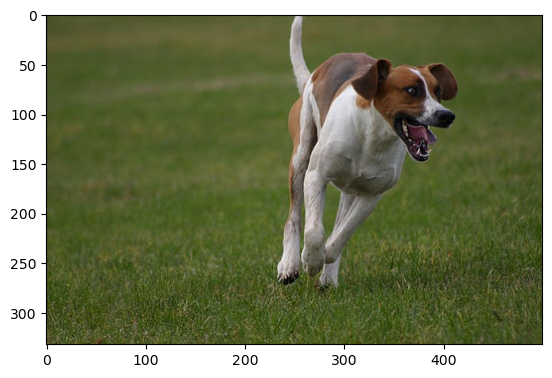

In [46]:
import pickle
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
#import argparse

# Directly assign the image path here (replace 'your_image_path.jpg' with the actual path)
img_path = r"C:\Users\shris\NewCaptionCraft\Images\284441196_8ebb216d0d.jpg"  # Provide the correct path to your image file

# Function to extract features from the image using Xception
def extract_features(filename, model):
    try:
        image = Image.open(filename)
    except:
        print("ERROR: Can't open image! Ensure that image path and extension is correct")
        return None
    
    image = image.resize((299, 299))  # Resize to match Xception input size
    image = np.array(image)
    
    # For 4-channel images (RGBA), convert them into 3 channels (RGB)
    if image.shape[2] == 4:
        image = image[..., :3]
    
    image = np.expand_dims(image, axis=0)
    image = image / 127.5
    image = image - 1.0
    feature = model.predict(image)
    return feature

# Function to convert integer to word using the tokenizer
def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

# Function to generate a description for the image
def generate_desc(model, tokenizer, photo, max_length):
    in_text = 'START\n'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence])
        pred = model.predict([photo, sequence], verbose=0)
        pred = np.argmax(pred)
        word = word_for_id(pred, tokenizer)
        
        if word is None:
            break
        in_text += ' ' + word
        
        if word == 'end':
            break
    return in_text

# Load model and tokenizer
#max_length = 33
max_length = 33
#tokenizer = load(open("tokenizer.p", "rb"))
tokenizer = pickle.load(open("tokenizer.p", "rb"))
model = load_model('models2/model_84.keras')

# Xception model for feature extraction
xception_model = Xception(include_top=False, pooling="avg")

# Extract features from the image
photo = extract_features(img_path, xception_model)

# If features are extracted, generate a description
if photo is not None:
    img = Image.open(img_path)
    description = generate_desc(model, tokenizer, photo, 10)
    print("Description:")
    print(description)
    plt.imshow(img)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Description:
START
 with bike rider on bike is riding on trail through the woods on the side of hill


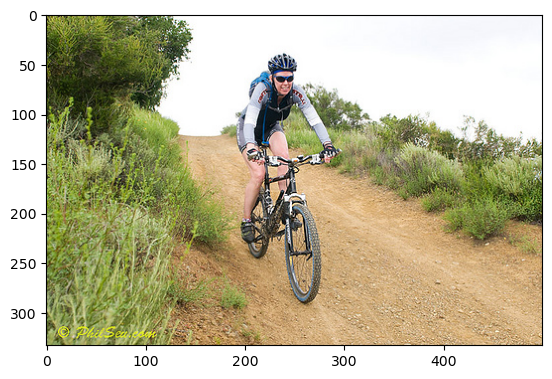

In [43]:
import pickle
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
#import argparse

# Directly assign the image path here (replace 'your_image_path.jpg' with the actual path)
img_path = r"C:\Users\shris\NewCaptionCraft\Images\3551787566_b5ebbe2440.jpg"  # Provide the correct path to your image file

# Function to extract features from the image using Xception
def extract_features(filename, model):
    try:
        image = Image.open(filename)
    except:
        print("ERROR: Can't open image! Ensure that image path and extension is correct")
        return None
    
    image = image.resize((299, 299))  # Resize to match Xception input size
    image = np.array(image)
    
    # For 4-channel images (RGBA), convert them into 3 channels (RGB)
    if image.shape[2] == 4:
        image = image[..., :3]
    
    image = np.expand_dims(image, axis=0)
    image = image / 127.5
    image = image - 1.0
    feature = model.predict(image)
    return feature

# Function to convert integer to word using the tokenizer
def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

# Function to generate a description for the image
def generate_desc(model, tokenizer, photo, max_length):
    in_text = 'START\n'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence])
        pred = model.predict([photo, sequence], verbose=0)
        pred = np.argmax(pred)
        word = word_for_id(pred, tokenizer)
        
        if word is None:
            break
        in_text += ' ' + word
        
        if word == 'end':
            break
    return in_text

# Load model and tokenizer
#max_length = 33
max_length = 33
#tokenizer = load(open("tokenizer.p", "rb"))
tokenizer = pickle.load(open("tokenizer.p", "rb"))
model = load_model('models2/model_83.keras')

# Xception model for feature extraction
xception_model = Xception(include_top=False, pooling="avg")

# Extract features from the image
photo = extract_features(img_path, xception_model)

# If features are extracted, generate a description
if photo is not None:
    img = Image.open(img_path)
    description = generate_desc(model, tokenizer, photo, 17)
    print("Description:")
    print(description)
    plt.imshow(img)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Description:
START
 and light dog running through green grass


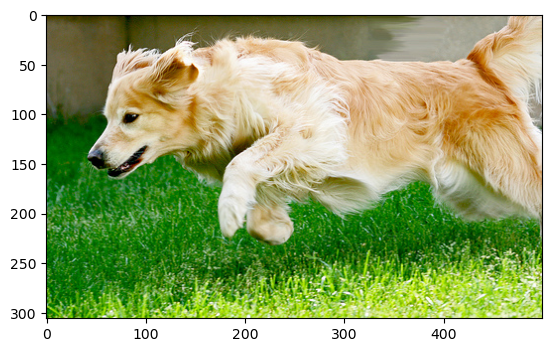

In [93]:
import pickle
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
#import argparse

# Directly assign the image path here (replace 'your_image_path.jpg' with the actual path)
img_path = r"C:\Users\shris\NewCaptionCraft\Images\3581818450_546c89ca38.jpg"  # Provide the correct path to your image file

# Function to extract features from the image using Xception
def extract_features(filename, model):
    try:
        image = Image.open(filename)
    except:
        print("ERROR: Can't open image! Ensure that image path and extension is correct")
        return None
    
    image = image.resize((299, 299))  # Resize to match Xception input size
    image = np.array(image)
    
    # For 4-channel images (RGBA), convert them into 3 channels (RGB)
    if image.shape[2] == 4:
        image = image[..., :3]
    
    image = np.expand_dims(image, axis=0)
    image = image / 127.5
    image = image - 1.0
    feature = model.predict(image)
    return feature

# Function to convert integer to word using the tokenizer
def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

# Function to generate a description for the image
def generate_desc(model, tokenizer, photo, max_length):
    in_text = 'START\n'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence])
        pred = model.predict([photo, sequence], verbose=0)
        pred = np.argmax(pred)
        word = word_for_id(pred, tokenizer)
        
        if word is None:
            break
        in_text += ' ' + word
        
        if word == 'end':
            break
    return in_text

# Load model and tokenizer
#max_length = 33
max_length = 33
#tokenizer = load(open("tokenizer.p", "rb"))
tokenizer = pickle.load(open("tokenizer.p", "rb"))
model = load_model('models2/model_84.keras')

# Xception model for feature extraction
xception_model = Xception(include_top=False, pooling="avg")

# Extract features from the image
photo = extract_features(img_path, xception_model)

# If features are extracted, generate a description
if photo is not None:
    img = Image.open(img_path)
    description = generate_desc(model, tokenizer, photo, 7)
    print("Description:")
    print(description)
    plt.imshow(img)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Description:
START
 with little girl is sitting on green chair


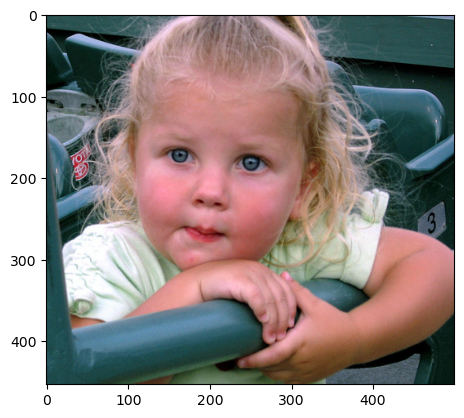

In [97]:
import pickle
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
#import argparse

# Directly assign the image path here (replace 'your_image_path.jpg' with the actual path)
img_path = r"C:\Users\shris\NewCaptionCraft\Images\367925122_335ed279a8.jpg"  # Provide the correct path to your image file

# Function to extract features from the image using Xception
def extract_features(filename, model):
    try:
        image = Image.open(filename)
    except:
        print("ERROR: Can't open image! Ensure that image path and extension is correct")
        return None
    
    image = image.resize((299, 299))  # Resize to match Xception input size
    image = np.array(image)
    
    # For 4-channel images (RGBA), convert them into 3 channels (RGB)
    if image.shape[2] == 4:
        image = image[..., :3]
    
    image = np.expand_dims(image, axis=0)
    image = image / 127.5
    image = image - 1.0
    feature = model.predict(image)
    return feature

# Function to convert integer to word using the tokenizer
def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

# Function to generate a description for the image
def generate_desc(model, tokenizer, photo, max_length):
    in_text = 'START\n'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence])
        pred = model.predict([photo, sequence], verbose=0)
        pred = np.argmax(pred)
        word = word_for_id(pred, tokenizer)
        
        if word is None:
            break
        in_text += ' ' + word
        
        if word == 'end':
            break
    return in_text

# Load model and tokenizer
#max_length = 33
max_length = 33
#tokenizer = load(open("tokenizer.p", "rb"))
tokenizer = pickle.load(open("tokenizer.p", "rb"))
model = load_model('models2/model_84.keras')

# Xception model for feature extraction
xception_model = Xception(include_top=False, pooling="avg")

# Extract features from the image
photo = extract_features(img_path, xception_model)

# If features are extracted, generate a description
if photo is not None:
    img = Image.open(img_path)
    description = generate_desc(model, tokenizer, photo, 8)
    print("Description:")
    print(description)
    plt.imshow(img)
    plt.show()

In [94]:
!pip install gTTS

In [95]:
from gtts import gTTS
import os

In [98]:
def Text_to_Speech(text,lang):
    audio_file=gTTS(text=text,lang=lang)
    audio_file.save("new_file.wav")
    os.system("new_file.wav")
Text_to_Speech(description,"en")